# 01 — Data Understanding & Cleaning

**Project:** Brisbane River Water Quality Analysis

## Purpose of this notebook

This notebook takes the raw Brisbane River water-quality monitoring dataset and turns it into
an analysis-ready dataset. It is the first stage of the project pipeline:

```
Raw Kaggle dataset  →  [this notebook]  →  data/processed/water_quality_cleaned.csv
```

## Dataset

- **Source:** [Kaggle — Water Quality Monitoring Dataset](https://www.kaggle.com/datasets/downshift/water-quality-monitoring-dataset)
  (Brisbane River monitoring buoy)
- **Location:** `data/raw/brisbane_water_quality.csv` (downloaded manually — see project README)
- **Content:** automated sensor readings from a river-monitoring buoy — water speed/direction,
  chlorophyll, temperature, dissolved oxygen, pH, salinity, specific conductance and turbidity —
  each logged roughly every 10–30 minutes.

## What this notebook does

1. Loads and inspects the raw data (structure, types, ranges, missingness, duplicates).
2. Investigates every data-quality issue found and makes an explicit, documented decision
   about how to handle it (`PROBLEM` / `DECISION` / `REASON` / `IMPACT`).
3. Applies only the cleaning that is justified by evidence — this dataset represents real
   environmental sensor readings, and legitimate extreme values or gaps (storms, sensor
   biofouling, maintenance outages) are part of the story, not noise to be deleted.
4. Engineers simple time-based features (`year`, `month`, `day`, `hour`, `day_of_week`, `season`)
   used throughout the rest of the project.
5. Exports the cleaned dataset and a data-quality summary.


## 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH = Path('../data/raw/brisbane_water_quality.csv')
PROCESSED_PATH = Path('../data/processed/water_quality_cleaned.csv')

print('pandas', pd.__version__)
print('numpy', np.__version__)


pandas 3.0.5
numpy 2.4.6


## 3. Load raw dataset

The raw file is not committed to the repository (see `.gitignore` and the README) — it must be
downloaded from Kaggle and placed at `data/raw/brisbane_water_quality.csv` before running this
notebook.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns from {RAW_PATH}')


Loaded 30,894 rows and 20 columns from ../data/raw/brisbane_water_quality.csv


## 4. Inspect first and last records

In [3]:
df_raw.head()

,Timestamp,Record number,Average Water Speed,Average Water Direction,Chlorophyll,Chlorophyll [quality],Temperature,Temperature [quality],Dissolved Oxygen,Dissolved Oxygen [quality],Dissolved Oxygen (%Saturation),Dissolved Oxygen (%Saturation) [quality],pH,pH [quality],Salinity,Salinity [quality],Specific Conductance,Specific Conductance [quality],Turbidity,Turbidity [quality]
0,2023-08-04 23:00:00,1468,4.834,73.484,1.621,NaN,20.018,NaN,7.472,NaN,101.175,NaN,8.176,NaN,35.215,NaN,53.262,NaN,2.068,NaN
1,2023-08-04 23:30:00,1469,2.544,106.424,1.959,NaN,19.986,NaN,7.455,NaN,100.884,NaN,8.175,NaN,35.209,NaN,53.254,NaN,1.994,NaN
2,2023-08-04 23:00:00,1470,1.260,156.755,1.620,NaN,20.001,NaN,7.430,NaN,100.571,NaN,8.171,NaN,35.207,NaN,53.252,NaN,2.030,NaN
3,2023-08-04 23:30:00,1471,0.760,281.754,1.761,NaN,19.983,NaN,7.419,NaN,100.398,NaN,8.171,NaN,35.211,NaN,53.257,NaN,1.973,NaN
4,2023-08-04 23:00:00,1472,3.397,244.637,1.635,NaN,19.986,NaN,7.429,NaN,100.538,NaN,8.171,NaN,35.208,NaN,53.253,NaN,1.944,NaN


In [4]:
df_raw.tail()

,Timestamp,Record number,Average Water Speed,Average Water Direction,Chlorophyll,Chlorophyll [quality],Temperature,Temperature [quality],Dissolved Oxygen,Dissolved Oxygen [quality],Dissolved Oxygen (%Saturation),Dissolved Oxygen (%Saturation) [quality],pH,pH [quality],Salinity,Salinity [quality],Specific Conductance,Specific Conductance [quality],Turbidity,Turbidity [quality]
30889,2024-06-27 08:20:00,32357,13.314,82.720,0.944,1020.0,18.607,1020.0,6.876,1020.0,87.556,1020.0,8.151,1020.0,29.268,1020.0,45.134,1020.0,3.963,1020.0
30890,2024-06-27 08:30:00,32358,32.617,18.081,1.161,1020.0,18.551,1020.0,6.918,1020.0,87.987,1020.0,8.163,1020.0,29.254,1020.0,45.115,1020.0,3.928,1020.0
30891,2024-06-27 08:40:00,32359,8.552,306.184,1.192,1020.0,18.558,1020.0,6.651,1020.0,84.606,1020.0,8.145,1020.0,29.250,1020.0,45.110,1020.0,4.097,1020.0
30892,2024-06-27 08:50:00,32360,10.341,24.711,1.031,1020.0,18.547,1020.0,6.740,1020.0,85.713,1020.0,8.154,1020.0,29.247,1020.0,45.105,1020.0,4.962,1020.0
30893,2024-06-27 09:00:00,32361,11.173,241.662,0.946,1020.0,18.562,1020.0,5.842,1020.0,74.326,1020.0,8.116,1020.0,29.258,1020.0,45.121,1020.0,5.078,1020.0


## 5. Dataset dimensions

In [5]:
print(f'Rows: {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')


Rows: 30,894
Columns: 20


## 6. Column names

The raw column names are human-readable but inconsistent for code (spaces, mixed case,
units embedded in names, `[quality]` suffixes). We list them here; the rename to clean,
`snake_case` names happens later in **Section 15 — Apply cleaning**, after all inspection
is finished (so every decision below is checked against the original names first).

In [6]:
for c in df_raw.columns:
    print(c)


Timestamp
Record number
Average Water Speed
Average Water Direction
Chlorophyll
Chlorophyll [quality]
Temperature
Temperature [quality]
Dissolved Oxygen
Dissolved Oxygen [quality]
Dissolved Oxygen (%Saturation)
Dissolved Oxygen (%Saturation) [quality]
pH
pH [quality]
Salinity
Salinity [quality]
Specific Conductance
Specific Conductance [quality]
Turbidity
Turbidity [quality]


## 7. Data types

`Timestamp` loads as a plain string/object — it needs explicit conversion to a proper
`datetime` type before any time-based analysis. Every measurement column is already numeric
(`float64`), which is expected for sensor readings.

In [7]:
df_raw.dtypes

Timestamp                                       str
Record number                                 int64
Average Water Speed                         float64
Average Water Direction                     float64
Chlorophyll                                 float64
Chlorophyll [quality]                       float64
Temperature                                 float64
Temperature [quality]                       float64
Dissolved Oxygen                            float64
Dissolved Oxygen [quality]                  float64
Dissolved Oxygen (%Saturation)              float64
Dissolved Oxygen (%Saturation) [quality]    float64
pH                                          float64
pH [quality]                                float64
Salinity                                    float64
Salinity [quality]                          float64
Specific Conductance                        float64
Specific Conductance [quality]              float64
Turbidity                                   float64
Turbidity [q

## 8. Descriptive statistics

In [8]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Record number,30894.0,16914.500000,8918.473945,1468.000,9191.25000,16914.5000,24637.750,32361.000
Average Water Speed,30874.0,16.799189,13.168964,0.000,6.59425,13.3905,23.600,89.912
Average Water Direction,30893.0,177.544711,103.621786,0.000,86.31400,176.3260,267.870,359.994
Chlorophyll,30309.0,2.782251,1.859404,0.100,1.45100,2.3710,3.650,43.301
Chlorophyll [quality],30086.0,1020.006648,1.153049,1020.000,1020.00000,1020.0000,1020.000,1220.000
Temperature,25730.0,24.415394,3.494728,17.000,21.29200,25.2455,27.254,32.063
Temperature [quality],25550.0,1021.673973,40.599400,1020.000,1020.00000,1020.0000,1020.000,2010.000
Dissolved Oxygen,26594.0,6.815158,0.620860,3.030,6.38700,6.8140,7.254,9.260
Dissolved Oxygen [quality],26370.0,1020.488055,21.976218,1020.000,1020.00000,1020.0000,1020.000,2010.000
Dissolved Oxygen (%Saturation),25145.0,96.641207,8.108339,51.836,92.22600,96.5130,101.668,134.082


## 9. Missing-value analysis

We look at *how much* is missing per column, and — critically for an environmental sensor
dataset — *when* it is missing. If missingness clusters in time, it likely reflects real
sensor outages/maintenance/biofouling rather than random data-entry problems, and should not
be casually imputed.

In [9]:
missing_counts = df_raw.isna().sum()
missing_pct = (missing_counts / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)


,missing_count,missing_pct
Dissolved Oxygen (%Saturation) [quality],5950,19.26
Dissolved Oxygen (%Saturation),5749,18.61
Temperature [quality],5344,17.30
Temperature,5164,16.72
Dissolved Oxygen [quality],4524,14.64
Dissolved Oxygen,4300,13.92
Salinity [quality],4182,13.54
Salinity,3958,12.81
Turbidity [quality],2224,7.20
Turbidity,2000,6.47


In [10]:
# Is missingness clustered in time, or spread randomly?
df_time = df_raw.copy()
df_time['Timestamp'] = pd.to_datetime(df_time['Timestamp'])
df_time['year_month'] = df_time['Timestamp'].dt.to_period('M')

key_measures = ['Temperature', 'Dissolved Oxygen', 'pH', 'Salinity',
                 'Specific Conductance', 'Turbidity', 'Chlorophyll']

missing_by_month = (
    df_time.groupby('year_month')[key_measures]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
missing_by_month


,Temperature,Dissolved Oxygen,pH,Salinity,Specific Conductance,Turbidity,Chlorophyll
year_month,,,,,,,
2023-08,0.1,1.2,0.1,0.1,0.1,0.2,0.3
2023-09,0.2,1.6,0.3,0.8,0.2,0.5,0.5
2023-10,0.0,12.4,0.0,60.8,0.7,28.6,1.2
2023-11,0.1,30.0,1.5,20.0,0.1,73.8,1.2
2023-12,54.2,50.2,3.4,19.8,0.1,0.2,1.8
2024-01,48.5,33.1,16.8,37.2,25.2,8.0,9.4
2024-02,0.5,1.0,3.6,5.3,5.0,0.8,0.6
2024-03,0.0,0.0,0.0,0.0,0.0,0.5,0.2
2024-04,0.0,0.0,0.0,0.0,0.0,0.6,0.1


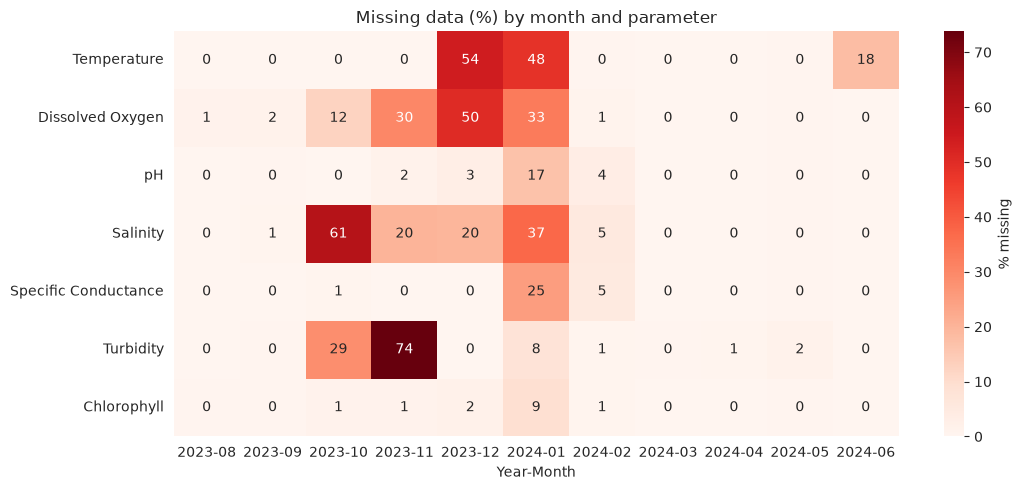

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(missing_by_month.T, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': '% missing'}, ax=ax)
ax.set_title('Missing data (%) by month and parameter')
ax.set_xlabel('Year-Month')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


**Reading the heatmap:** missingness is *not* random. `Dissolved Oxygen` misses more and
more from Oct 2023 through a peak in Dec 2023, then recovers — consistent with gradual sensor
biofouling followed by a cleaning/calibration event. `Temperature` and `Specific Conductance`
spike sharply in Dec 2023–Jan 2024, suggesting a shared outage or maintenance visit affecting
several sensors on the buoy at once. This pattern is documented explicitly in the cleaning
decisions (Section 14) and is treated as a genuine limitation of the dataset, not something to
paper over with imputation.

## 10. Duplicate analysis

We check for duplicates at two levels: fully identical rows, and repeated `Timestamp` values
(which would break any per-timestamp time-series indexing).

In [12]:
full_duplicates = df_raw.duplicated().sum()
print(f'Fully duplicated rows: {full_duplicates}')

duplicate_record_numbers = df_raw['Record number'].duplicated().sum()
print(f'Duplicate Record number values: {duplicate_record_numbers}')

duplicate_timestamps = df_raw['Timestamp'].duplicated().sum()
print(f'Rows sharing a Timestamp with another row: {duplicate_timestamps}')


Fully duplicated rows: 0
Duplicate Record number values: 0
Rows sharing a Timestamp with another row: 280


In [13]:
# Inspect a sample of duplicate-timestamp rows
dup_ts_mask = df_raw['Timestamp'].duplicated(keep=False)
df_raw.loc[dup_ts_mask, ['Timestamp', 'Record number', 'Temperature', 'pH']].head(10)


,Timestamp,Record number,Temperature,pH
0,2023-08-04 23:00:00,1468,20.018,8.176
1,2023-08-04 23:30:00,1469,19.986,8.175
2,2023-08-04 23:00:00,1470,20.001,8.171
3,2023-08-04 23:30:00,1471,19.983,8.171
4,2023-08-04 23:00:00,1472,19.986,8.171
5,2023-08-04 23:00:00,1473,19.834,8.158
6,2023-08-04 23:30:00,1474,19.829,8.158
455,2023-08-14 08:00:00,1923,20.076,8.136
456,2023-08-14 08:00:00,1924,20.076,8.136
463,2023-08-14 11:30:00,1931,20.605,8.134


**Interpretation:** there are **zero** fully duplicated rows and **zero** duplicate
`Record number` values — `Record number` is a reliable unique key for every reading. The 280
rows that *share* a `Timestamp` with another row have consecutive, distinct `Record number`
values and slightly different measurements, which tells us they are genuine, separate sensor
readings — the `Timestamp` field is simply recorded at coarser (30-minute) granularity than the
true ~10-minute sampling rate at those points. This is a logging/export quirk, not duplicate
data, so no rows are dropped for this reason (see Section 14).

## 11. Invalid-value analysis

We check each measurement against a plausible physical range for a river environment, to catch
sensor faults (e.g. negative turbidity, pH outside 0–14) rather than to police natural
variability.

In [14]:
measure_cols = ['Average Water Speed', 'Average Water Direction', 'Chlorophyll', 'Temperature',
                'Dissolved Oxygen', 'Dissolved Oxygen (%Saturation)', 'pH', 'Salinity',
                'Specific Conductance', 'Turbidity']

ranges = df_raw[measure_cols].agg(['min', 'max']).T
ranges


,min,max
Average Water Speed,0.000,89.912
Average Water Direction,0.000,359.994
Chlorophyll,0.100,43.301
Temperature,17.000,32.063
Dissolved Oxygen,3.030,9.260
Dissolved Oxygen (%Saturation),51.836,134.082
pH,7.309,8.255
Salinity,0.057,36.000
Specific Conductance,0.021,54.996
Turbidity,0.335,49.869


In [15]:
invalid_checks = {
    'Negative values (any measurement that cannot be negative)':
        (df_raw[measure_cols] < 0).any(axis=1).sum(),
    'pH outside 0-14':
        ((df_raw['pH'] < 0) | (df_raw['pH'] > 14)).sum(),
    'Water direction outside 0-360 degrees':
        ((df_raw['Average Water Direction'] < 0) | (df_raw['Average Water Direction'] > 360)).sum(),
    'Dissolved Oxygen %Saturation implausibly high (>200%)':
        (df_raw['Dissolved Oxygen (%Saturation)'] > 200).sum(),
    'Rows with every measurement missing':
        df_raw[measure_cols].isna().all(axis=1).sum(),
}
for check, count in invalid_checks.items():
    print(f'{check}: {count}')


Negative values (any measurement that cannot be negative): 0
pH outside 0-14: 0
Water direction outside 0-360 degrees: 0
Dissolved Oxygen %Saturation implausibly high (>200%): 0
Rows with every measurement missing: 0


**Result:** no rows fail these physical plausibility checks — every value observed sits
within a realistic range for a subtropical river (e.g. pH 7.3–8.3, dissolved oxygen saturation
up to 134%, which is elevated but consistent with daytime photosynthetic activity rather than a
sensor fault). No records are removed for invalid values.

## 12. Date/time analysis

In [16]:
df_time['Timestamp'] = pd.to_datetime(df_time['Timestamp'])
print('Earliest reading:', df_time['Timestamp'].min())
print('Latest reading:  ', df_time['Timestamp'].max())
print('Total span:      ', df_time['Timestamp'].max() - df_time['Timestamp'].min())


Earliest reading: 2023-08-04 23:00:00
Latest reading:   2024-06-27 09:00:00
Total span:       327 days 10:00:00


In [17]:
# Sampling interval between consecutive readings
intervals = df_time.sort_values('Timestamp')['Timestamp'].diff().value_counts().head(10)
intervals


Timestamp
0 days 00:10:00     24781
0 days 00:30:00      5827
0 days 00:00:00       280
0 days 00:11:00         1
0 days 00:19:00         1
0 days 00:20:00         1
3 days 10:40:00         1
30 days 10:50:00        1
Name: count, dtype: int64

In [18]:
# Any unusually large gaps (possible sensor/logger outages)?
sorted_ts = df_time.sort_values('Timestamp')['Timestamp']
gaps = sorted_ts.diff()
large_gaps = gaps[gaps > pd.Timedelta(hours=2)]
gap_report = pd.DataFrame({
    'gap_ends_at': sorted_ts.loc[large_gaps.index],
    'gap_duration': large_gaps.values,
})
gap_report


,gap_ends_at,gap_duration
24651,2024-04-14 20:20:00,3 days 10:40:00
25022,2024-05-17 20:50:00,30 days 10:50:00


**Interpretation:** readings are logged roughly every 10 or 30 minutes for the vast
majority of the dataset. There are two much larger gaps — about 3.4 days in April 2024 and
about 30 days in April–May 2024 — almost certainly a real equipment outage or maintenance
period rather than a data error. These gaps are **kept** (not interpolated across) so that
later time-series analysis doesn't invent readings for a period the buoy simply wasn't
recording.

## 13. Outlier investigation

We use boxplots and the IQR rule purely to *see* how many extreme values each parameter has —
not to remove them. In an environmental time series, an "outlier" can be a real event (a storm
pushing turbidity up, a low-tide salinity spike) that is exactly what an environmental analyst
should investigate further, not delete.

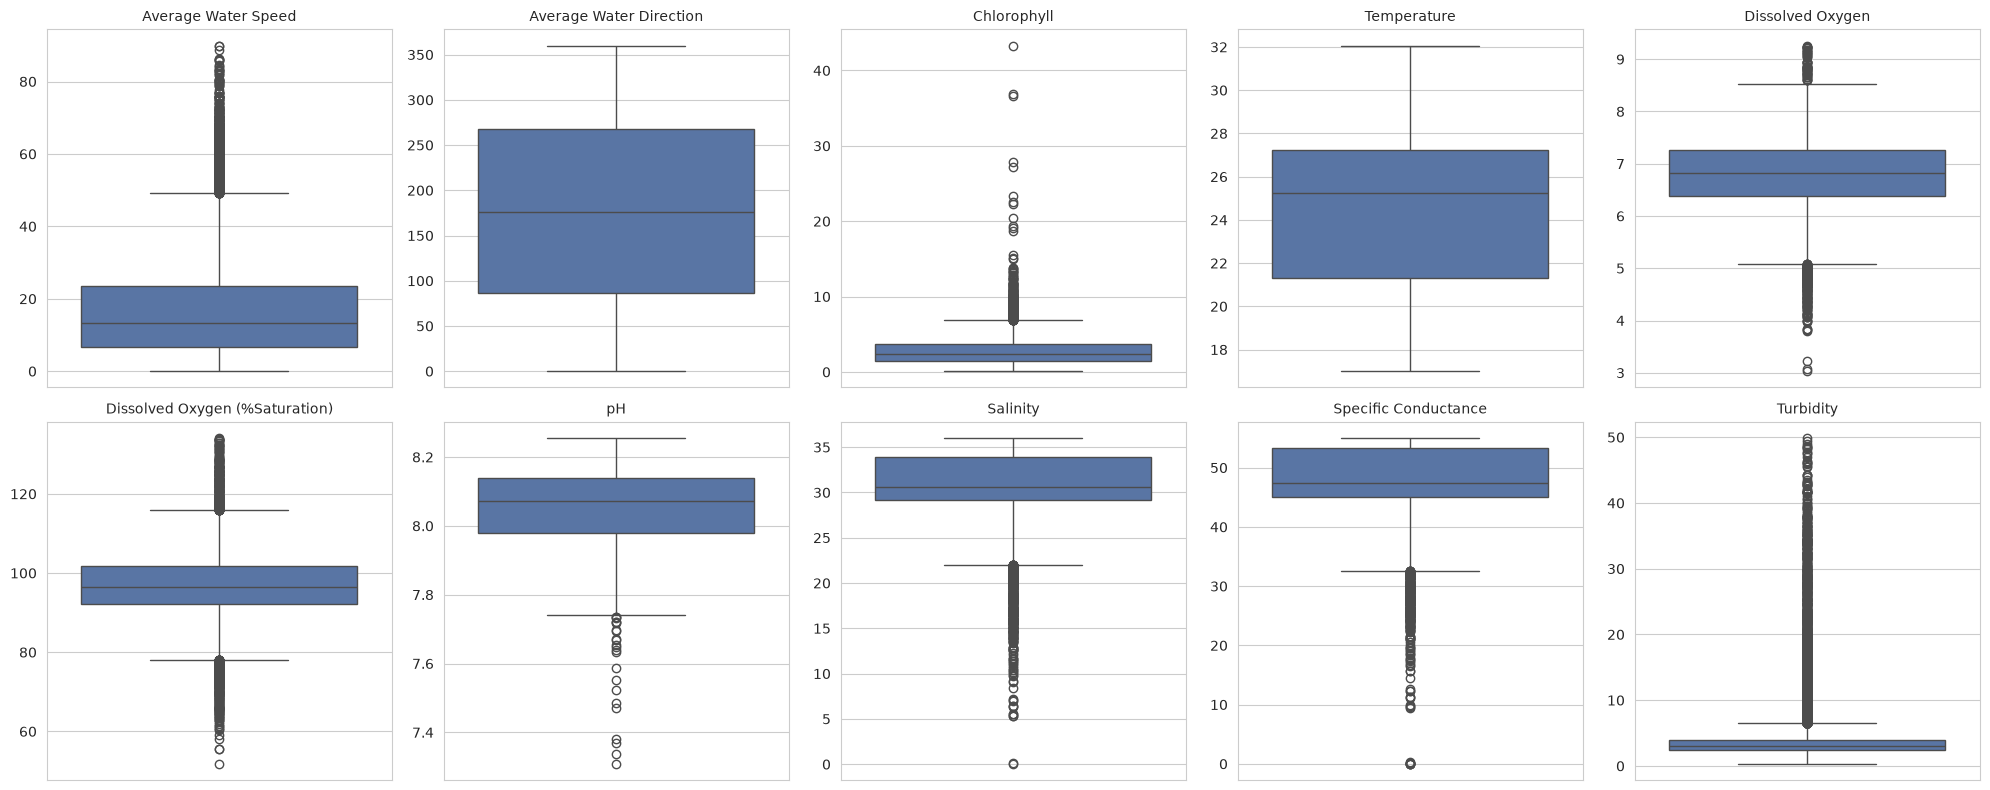

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for ax, col in zip(axes, measure_cols):
    sns.boxplot(y=df_raw[col].dropna(), ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [20]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.Series(
    {col: iqr_outlier_count(df_raw[col].dropna()) for col in measure_cols},
    name='iqr_outlier_count'
).sort_values(ascending=False)
outlier_summary


Turbidity                         2670
Chlorophyll                       1012
Average Water Speed                865
Dissolved Oxygen (%Saturation)     720
Salinity                           441
Specific Conductance               368
Dissolved Oxygen                   265
pH                                  23
Average Water Direction              0
Temperature                          0
Name: iqr_outlier_count, dtype: int64

**Decision:** `Average Water Speed` and `Turbidity` show the most IQR-flagged extreme
values — both are expected to spike during high-flow or storm events on a river, which is
genuine environmental signal. No values are removed on the basis of this check alone; potential
abnormal periods are investigated properly with their timestamps in Notebook 2 (RQ6), where we
can see *when* they occur rather than just flagging them statistically.

## 14. Data-cleaning decisions

Summary of every issue investigated above, and the decision made for each.

| # | PROBLEM | DECISION | REASON | IMPACT |
|---|---------|----------|--------|--------|
| 1 | Column names are inconsistent (spaces, mixed case, units in names) | Rename to clean `snake_case` names | Easier, less error-prone code in this notebook and downstream scripts | No data changes, purely cosmetic |
| 2 | `Timestamp` loaded as text | Convert to `datetime64` | Required for any time-based analysis, resampling, or feature engineering | No rows affected |
| 3 | Missing values in every measurement column (0.1%–19% depending on column), clustered by month (see Section 9) | **Keep as `NaN`. Do not impute or interpolate.** | Missingness is concentrated in specific months per sensor (e.g. Dissolved Oxygen degrading through Oct–Dec 2023), consistent with real sensor biofouling/maintenance — imputing values would fabricate readings for periods the sensor was genuinely not producing reliable data | 0 rows removed; downstream aggregations use `skipna=True` (pandas default) so months with heavy gaps will show lower sample counts, which is itself informative |
| 4 | 280 rows share a `Timestamp` with another row | **Keep all rows.** Do not drop as duplicates. | Each has a unique, sequential `Record number` and distinct measurement values — they are genuine separate readings; the `Timestamp` field is just recorded at coarser resolution than the true sampling rate at those points | 0 rows removed |
| 5 | Two large time gaps (~3.4 days, ~30 days) with no readings | **Keep as a real gap.** Do not interpolate across it. | Represents an actual equipment outage, not a data error | 0 rows removed; time-series plots will show a visible break, which is accurate |
| 6 | `[quality]` flag columns are inconsistently populated (more missing than the measurement itself, undocumented code values) | **Retain the columns but do not use them to filter/drop rows.** Treat as informational only. | The flags are not documented by the data source and are missing even when the underlying measurement is present, so they cannot be trusted as an authoritative pass/fail signal | 0 rows removed |
| 7 | Statistical outliers (IQR rule) present in most parameters, especially Water Speed and Turbidity | **Keep all values.** No automatic removal. | River conditions genuinely include high-flow/storm events; deleting them would remove real environmental signal | 0 rows removed; explored further as "potential abnormal periods" in Notebook 2 |
| 8 | No time-based features (year, month, season, etc.) | **Engineer new columns** from `Timestamp` | Needed for the temporal/seasonal analysis in Notebooks 2–3 and the SQL scripts | Adds new columns, no rows affected |

**Net result: 0 rows are removed from the raw dataset.** Every row observed in the raw CSV survives
cleaning; what changes is data *typing*, column *naming*, and the addition of derived time
features. This is a deliberate choice — the investigation above found no invalid or duplicate
records, only real, explainable data-collection characteristics that a subsequent analysis
should be aware of rather than have hidden from it.

## 15. Apply cleaning

In [21]:
df = df_raw.copy()

# Rename columns to clean, consistent snake_case names
column_map = {
    'Timestamp': 'timestamp',
    'Record number': 'record_number',
    'Average Water Speed': 'water_speed',
    'Average Water Direction': 'water_direction',
    'Chlorophyll': 'chlorophyll',
    'Chlorophyll [quality]': 'chlorophyll_quality',
    'Temperature': 'temperature',
    'Temperature [quality]': 'temperature_quality',
    'Dissolved Oxygen': 'dissolved_oxygen',
    'Dissolved Oxygen [quality]': 'dissolved_oxygen_quality',
    'Dissolved Oxygen (%Saturation)': 'dissolved_oxygen_pct_sat',
    'Dissolved Oxygen (%Saturation) [quality]': 'dissolved_oxygen_pct_sat_quality',
    'pH': 'ph',
    'pH [quality]': 'ph_quality',
    'Salinity': 'salinity',
    'Salinity [quality]': 'salinity_quality',
    'Specific Conductance': 'specific_conductance',
    'Specific Conductance [quality]': 'specific_conductance_quality',
    'Turbidity': 'turbidity',
    'Turbidity [quality]': 'turbidity_quality',
}
df = df.rename(columns=column_map)

# Convert timestamp to datetime and sort chronologically
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(df.shape)
df.head()


(30894, 20)


,timestamp,record_number,water_speed,water_direction,chlorophyll,chlorophyll_quality,temperature,temperature_quality,dissolved_oxygen,dissolved_oxygen_quality,dissolved_oxygen_pct_sat,dissolved_oxygen_pct_sat_quality,ph,ph_quality,salinity,salinity_quality,specific_conductance,specific_conductance_quality,turbidity,turbidity_quality
0,2023-08-04 23:00:00,1468,4.834,73.484,1.621,NaN,20.018,NaN,7.472,NaN,101.175,NaN,8.176,NaN,35.215,NaN,53.262,NaN,2.068,NaN
1,2023-08-04 23:00:00,1470,1.260,156.755,1.620,NaN,20.001,NaN,7.430,NaN,100.571,NaN,8.171,NaN,35.207,NaN,53.252,NaN,2.030,NaN
2,2023-08-04 23:00:00,1472,3.397,244.637,1.635,NaN,19.986,NaN,7.429,NaN,100.538,NaN,8.171,NaN,35.208,NaN,53.253,NaN,1.944,NaN
3,2023-08-04 23:00:00,1473,1.596,100.271,1.935,NaN,19.834,NaN,7.430,NaN,100.293,NaN,8.158,NaN,35.255,NaN,53.315,NaN,2.124,NaN
4,2023-08-04 23:30:00,1469,2.544,106.424,1.959,NaN,19.986,NaN,7.455,NaN,100.884,NaN,8.175,NaN,35.209,NaN,53.254,NaN,1.994,NaN


## 16. Feature engineering

Brisbane is in the Southern Hemisphere, so meteorological seasons are shifted relative to the
Northern Hemisphere convention (Summer = Dec–Feb, Winter = Jun–Aug).

In [22]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return 'Summer'
    if month in (3, 4, 5):
        return 'Autumn'
    if month in (6, 7, 8):
        return 'Winter'
    return 'Spring'  # 9, 10, 11

df['season'] = df['month'].apply(month_to_season)

df[['timestamp', 'year', 'month', 'day', 'hour', 'day_of_week', 'season']].head()


,timestamp,year,month,day,hour,day_of_week,season
0,2023-08-04 23:00:00,2023,8,4,23,Friday,Winter
1,2023-08-04 23:00:00,2023,8,4,23,Friday,Winter
2,2023-08-04 23:00:00,2023,8,4,23,Friday,Winter
3,2023-08-04 23:00:00,2023,8,4,23,Friday,Winter
4,2023-08-04 23:30:00,2023,8,4,23,Friday,Winter


## 17. Validate cleaned dataset

In [23]:
assert df.shape[0] == df_raw.shape[0], 'Row count changed unexpectedly during cleaning'
assert df['record_number'].is_unique, 'record_number should be a unique key'
assert df['timestamp'].dtype.kind == 'M', 'timestamp should be a datetime dtype'
assert df['season'].isna().sum() == 0, 'every row should have a season'
assert set(df['season'].unique()) == {'Summer', 'Autumn', 'Winter', 'Spring'}

print('All validation checks passed.')
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.dtypes


All validation checks passed.
Final shape: 30,894 rows x 26 columns


timestamp                           datetime64[us]
record_number                                int64
water_speed                                float64
water_direction                            float64
chlorophyll                                float64
chlorophyll_quality                        float64
temperature                                float64
temperature_quality                        float64
dissolved_oxygen                           float64
dissolved_oxygen_quality                   float64
dissolved_oxygen_pct_sat                   float64
dissolved_oxygen_pct_sat_quality           float64
ph                                         float64
ph_quality                                 float64
salinity                                   float64
salinity_quality                           float64
specific_conductance                       float64
specific_conductance_quality               float64
turbidity                                  float64
turbidity_quality              

## 18. Data-quality summary

In [24]:
quality_summary = pd.DataFrame({
    'metric': [
        'Original records (raw CSV)',
        'Fully duplicated rows found',
        'Duplicate Record number values found',
        'Rows failing physical-plausibility checks',
        'Records removed during cleaning',
        'Final records (cleaned dataset)',
    ],
    'value': [
        len(df_raw),
        int(full_duplicates),
        int(duplicate_record_numbers),
        0,
        0,
        len(df),
    ]
})
quality_summary


,metric,value
0,Original records (raw CSV),30894
1,Fully duplicated rows found,0
2,Duplicate Record number values found,0
3,Rows failing physical-plausibility checks,0
4,Records removed during cleaning,0
5,Final records (cleaned dataset),30894


## Export cleaned dataset

The cleaned, feature-engineered dataset is saved to `data/processed/water_quality_cleaned.csv`
for use in Notebook 2, Notebook 3, and the SQL scripts.

In [25]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)
print(f'Saved {len(df):,} rows to {PROCESSED_PATH}')


Saved 30,894 rows to ../data/processed/water_quality_cleaned.csv


## What to take away from this notebook

- The raw dataset is high-frequency river sensor data (~11 months, ~10-30 min readings) with
  real-world data-collection characteristics: uneven missingness by sensor and time period,
  a coarser `Timestamp` resolution than the true sampling rate at some points, and two genuine
  multi-day equipment outages.
- **No rows were removed.** Every cleaning decision here was investigated with evidence first
  (missing-by-month heatmap, physical range checks, duplicate inspection) rather than applying
  blanket rules like "drop all NaNs" or "remove outliers by IQR" — those would have destroyed
  real environmental signal (storm events, sensor drift) or introduced fabricated data.
  This restraint is itself a defensible, explainable data-engineering decision.
- Six new time-based columns (`year`, `month`, `day`, `hour`, `day_of_week`, `season`) are now
  available for the temporal and seasonal analysis in Notebook 2.
- The cleaned dataset still contains missing values by design — any downstream analysis must
  continue to handle `NaN`s correctly (e.g. `skipna=True` aggregations, checking sample counts
  per group) rather than assuming a complete dataset.
